In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/customer_churn_dataset.csv'
)

In [3]:
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             4338 non-null   float64
 1   LastPurchase           4338 non-null   object 
 2   FirstPurchase          4338 non-null   object 
 3   TotalOrders            4338 non-null   int64  
 4   Revenue                4338 non-null   float64
 5   CustomerAge            4338 non-null   int64  
 6   DaysSinceLastPurchase  4338 non-null   int64  
 7   Churn                  4338 non-null   int64  
 8   Segment                4338 non-null   object 
dtypes: float64(2), int64(4), object(3)
memory usage: 305.1+ KB


,0
CustomerID,0
LastPurchase,0
FirstPurchase,0
TotalOrders,0
Revenue,0
CustomerAge,0
DaysSinceLastPurchase,0
Churn,0
Segment,0


In [13]:
features = [
    'Revenue',
    'TotalOrders',
    'CustomerAge'
]

In [14]:
target = 'Churn'

In [15]:
X = df[features]
y = df[target]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
lr = LogisticRegression( random_state=42)
lr.fit( X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [19]:
y_pred_lr = lr.predict(X_test_scaled)

In [20]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       579
           1       0.75      0.72      0.73       289

    accuracy                           0.83       868
   macro avg       0.81      0.80      0.80       868
weighted avg       0.83      0.83      0.83       868



In [21]:
print(
    "Accuracy:",
    accuracy_score(y_test,y_pred_lr)
)

print(
    "Precision:",
    precision_score(y_test,y_pred_lr)
)

print(
    "Recall:",
    recall_score(y_test,y_pred_lr)
)

print(
    "F1:",
    f1_score(y_test,y_pred_lr)
)

Accuracy: 0.8271889400921659
Precision: 0.7509025270758123
Recall: 0.7197231833910035
F1: 0.734982332155477


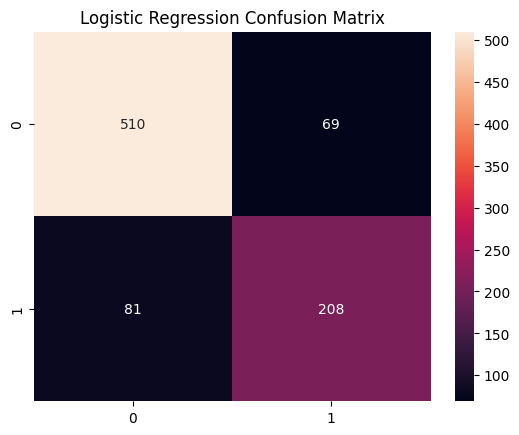

In [23]:
cm = confusion_matrix(y_test,y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Logistic Regression Confusion Matrix')
plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/Logistic Regression Confusion Matrix.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [24]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

In [25]:
y_pred_rf = rf.predict(X_test)

In [26]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       579
           1       0.85      0.74      0.79       289

    accuracy                           0.87       868
   macro avg       0.87      0.84      0.85       868
weighted avg       0.87      0.87      0.87       868



In [27]:
print(
    "Accuracy:",
    accuracy_score(y_test,y_pred_rf)
)

print(
    "Precision:",
    precision_score(y_test,y_pred_rf)
)

print(
    "Recall:",
    recall_score(y_test,y_pred_rf)
)

print(
    "F1:",
    f1_score(y_test,y_pred_rf)
)

Accuracy: 0.8709677419354839
Precision: 0.852589641434263
Recall: 0.740484429065744
F1: 0.7925925925925926


In [28]:
results = pd.DataFrame({
    'Model':['Logistic Regression','Random Forest'],
    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf)
    ],
    'Precision':[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf)
    ],
    'Recall':[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf)
    ],
    'F1':[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.827189,0.750903,0.719723,0.734982
1,Random Forest,0.870968,0.852590,0.740484,0.792593


In [29]:
results.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/model_comparison.csv',
    index=False
)

In [30]:
importance = pd.DataFrame({
    'Feature':features,
    'Importance':rf.feature_importances_
})

In [40]:
importance = (
    importance.sort_values(
        'Importance',
        ascending=False
    )
)
importance.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/feature_importance.csv',
    index=False
)

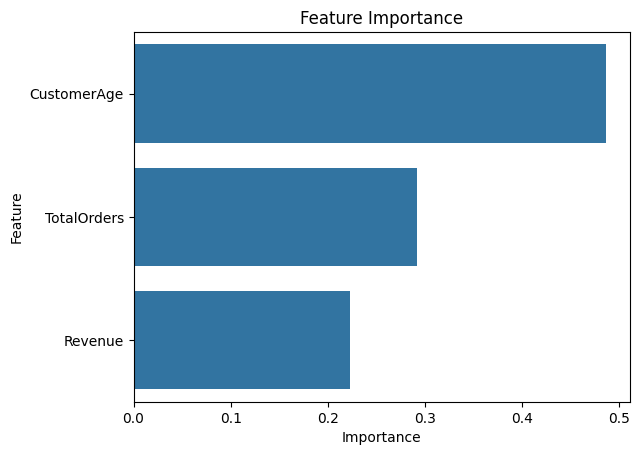

In [33]:
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')
plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/Feature Importance.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [34]:
y_prob = rf.predict_proba(X_test)[:,1]

In [35]:
roc_auc_score(y_test,y_prob)

np.float64(0.9453209506905474)

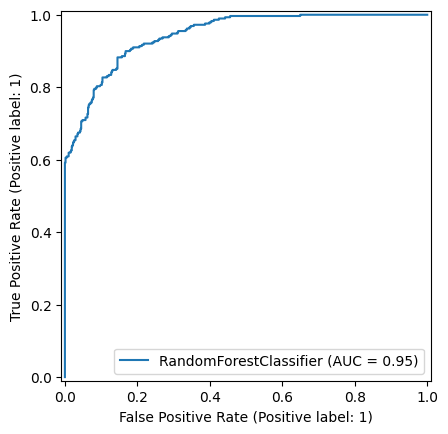

In [36]:
RocCurveDisplay.from_estimator(rf,X_test,y_test)
plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/RocCurveDisplay.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [37]:
df['ChurnProbability'] = (rf.predict_proba(X)[:,1])

In [38]:
df.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/customer_churn_predictions.csv',
    index=False
)

Feature importance analysis revealed that CustomerAge was the strongest predictor of churn, followed by TotalOrders and Revenue.

This suggests that customer tenure and engagement frequency are more important indicators of future churn than spending behavior alone.

Customers with shorter tenure and fewer purchases exhibit a higher likelihood of churning, highlighting the importance of early customer engagement and repeat-purchase strategies.